# 이미지분석_사진유사도비교_서비스_mediapipe_deepface

In [ ]:
# 이미지 유사도 분석 모델 다운로드
!wget -O embedder.tflite -q https://storage.googleapis.com/mediapipe-models/image_embedder/mobilenet_v3_small/float32/1/mobilenet_v3_small.tflite

In [1]:
import urllib
import cv2
import math
import matplotlib.pyplot as plt

In [2]:
image_filenames = ['burger.jpg', 'burger_crop.jpg']

for name in image_filenames:
    url = f"https://storage.googleapis.com/mediapipe-assets/{name}"
    urllib.request.urlretrieve(url, name)

In [3]:
desired_height = 480
desired_width = 480

In [4]:
def resize_and_show(image):
    h, w = image.shape[:2]
    if h < w:
        img = cv2.resize(image, (desired_width, math.floor(h/(w/desired_width))))
    else:
        img = cv2.resize(image, (math.floor(w/(h/desired_height)), desired_height))
    return img
        
                         

burger.jpg


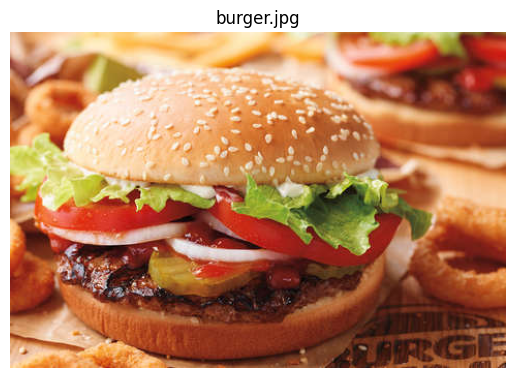

burger_crop.jpg


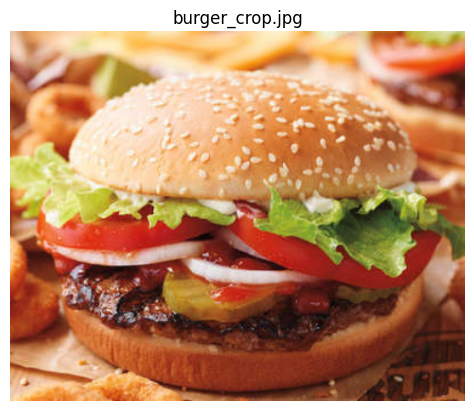

In [5]:
# 이미지 미리보기
images = {name: cv2.imread(name) for name in image_filenames}
for name, image in images.items():
    print(name)
    resized_image = resize_and_show(image)
    plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
    plt.title(name)
    plt.axis('off')
    plt.show()

# 미디어 파이프 모델을 불러와서 유사도 분석

In [11]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [12]:
base_options = python.BaseOptions(model_asset_path="./embedder.tflite")
l2_normalize = True
quantize = True
options = vision.ImageEmbedderOptions(
        base_options=base_options, l2_normalize=l2_normalize, quantize=quantize
        )

# create image embedder
with vision.ImageEmbedder.create_from_options(options) as embedder:
    first_image = mp.Image.create_from_file(image_filenames[0])
    second_image = mp.Image.create_from_file(image_filenames[1])
    first_embedding_result = embedder.embed(first_image)
    second_embedding_result = embedder.embed(second_image)
    
    #유사도 비교(코사인 유사도 사용)
    similarity = vision.ImageEmbedder.cosine_similarity(
            first_embedding_result.embeddings[0],
            second_embedding_result.embeddings[0])
    print(similarity)
    

0.9154104779706991


I0000 00:00:1747873586.835909     640 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1747873586.847500    1517 gl_context.cc:369] GL version: 3.0 (OpenGL ES 3.0 Mesa 23.2.1-1ubuntu3.1~22.04.3), renderer: D3D12 (Intel(R) UHD Graphics)


# 미디어 파이프 모델로 얼굴 유사도 판별하기
* 사진 2장 필요
* 사진에서 얼굴 찾기 - 얼굴 찾는 모델
* 얼굴만 크롭
* 얼굴을 숫자로 임베딩 - 이미지를 숫자로 벡터화(임베딩)하는 모델
* 임베딩 된 얼굴을 비교
* 유사도 출력
* 간단한 서비스 구현을 위해 gradio라이브러리 활용

In [13]:
# !pip install gradio

In [14]:
import gradio as gr
import numpy as np

# 사진에서 얼굴 추출하는 함수 작성

In [15]:
def crop_face(image_np):
    mp_face_detection = mp.solutions.face_detection
    with mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5) as detector:
        results = detector.process(cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB))
        if not results.detections:
            return None
        bbox = results.detections[0].location_data.relative_bounding_box
        h, w, _ = image_np.shape
        x_min = int(bbox.xmin * w)
        y_min = int(bbox.ymin * h)
        width = int(bbox.width * w)
        height = int(bbox.height * h)
        return image_np[y_min:y_min+height, x_min:x_min+width]

# 얼굴 유사도 비교 함수 작성

In [16]:
def image_to_text(image1, image2):
    # 이미지 없는 경우 예외처리
    if image1 is None or image2 is None:
        return "이미지를 두 장 모두 업로드하세요."
    
    img1 = cv2.cvtColor(np.array(image1), cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(np.array(image2), cv2.COLOR_BGR2RGB)
    
    # crop_face함수로 얼굴만 추출해서 저장
    face1 = crop_face(img1)
    face2 = crop_face(img2)
    
    if face1 is None or face2 is None:
        return "얼굴 감지 실패"
    
    cv2.imwrite("face1.jpg", face1)
    cv2.imwrite("face2.jpg", face2)
    
    base_options = python.BaseOptions(model_asset_path="./embedder.tflite")
    options = vision.ImageEmbedderOptions(
            base_options=base_options, l2_normalize=True, quantize=True
            )

    # create image embedder
    with vision.ImageEmbedder.create_from_options(options) as embedder:
        face1_mp = mp.Image.create_from_file("face1.jpg")
        face2_mp = mp.Image.create_from_file("face2.jpg")
        emb1 = embedder.embed(face1_mp).embeddings[0]
        emb2 = embedder.embed(face2_mp).embeddings[0]

        #유사도 비교(코사인 유사도 사용)
        similarity = vision.ImageEmbedder.cosine_similarity(
                emb1,
                emb2)
        return f"얼굴 유사도: {similarity:.4f}"

# gradio를 이용해서 UI 및 간이 서버 만들기
* 내부적으로 fastapi 프레임워크 사용: 웹서버

In [17]:
with gr.Blocks() as app:
    gr.Markdown("얼굴 유사도 비교")
    
    with gr.Tab('Image Upload'):
        with gr.Column():
            image1 = gr.Image(label="First Image")
        with gr.Column():
            image2 = gr.Image(label="Second Image")
    output = gr.Textbox(label="얼굴 유사도: ")
    convert_btn = gr.Button("유사도 비교하기")
    convert_btn.click(
        fn=image_to_text, inputs=[image1, image2], outputs=output)
app.launch(inline=False, share=True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://0b05084e71d2d3e0e6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


I0000 00:00:1747873613.955668    1530 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1747873613.966584    1554 gl_context.cc:369] GL version: 3.0 (OpenGL ES 3.0 Mesa 23.2.1-1ubuntu3.1~22.04.3), renderer: D3D12 (Intel(R) UHD Graphics)
W0000 00:00:1747873613.982635    1547 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1747873614.004670    1530 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1747873614.017153    1563 gl_context.cc:369] GL version: 3.0 (OpenGL ES 3.0 Mesa 23.2.1-1ubuntu3.1~22.04.3), renderer: D3D12 (Intel(R) UHD Graphics)
W0000 00:00:1747873614.029370    1557 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1747873614.058822    1530 gl_context_egl.cc:85] Successfully initialized EGL. Major 

# Deepface를 이용해 정확도 높은 얼굴인식 프로그램 만들기

In [ ]:
# !pip install deepface
# !pip install tf-keras

In [5]:
import gradio as gr
from deepface import DeepFace
import cv2
import numpy as np

# 유사도 %로 표시하는 함수 작성

In [18]:
def convert_distance_to_similarity(distance,threshold, verified):
    if verified:
        #일치할 경우
        ratio = max(0, 1 -(distance/threshold))
        return round(90 + ratio * 10, 2)
    else:
        # 불일치 할 경우
        ratio = max(0, 1 - (distance/ (threshold * 2)))
        return round(ratio * 60, 2)
    

# 얼굴 유사도 비교 함수 (ArcFace)

In [11]:
def image_to_text(image1, image2):
    if image1 is None or image2 is None:
        return "두 이미지 모두 업로드 해주세요."
    image1 = cv2.cvtColor(np.array(image1), cv2.COLOR_RGB2BGR)
    image2 = cv2.cvtColor(np.array(image2), cv2.COLOR_RGB2BGR)
    cv2.imwrite("image1.jpg", image1)
    cv2.imwrite("image2.jpg", image2)
    
    try:
        threshold = 0.68 # ArcFace 기준 두 이미지가 일치하는 기준
        result = DeepFace.verify("image1.jpg", "image2.jpg", model_name="ArcFace", enforce_detection=True)
        distance = result['distance']
        verified = result['verified']
        similarity_score = convert_distance_to_similarity(distance, threshold, verified)
        result_text = f"ArcFace 기준 얼굴 유사도 분석:\n유사도: {similarity_score:.2f}%\n얼굴 일치 여부: {'일치' if verified else '불일치'}"
        return result_text
    except Exception as e:
        return f"오류: {str(e)}" 
    

# Gradio로 입출력 인터페이스 만들기

In [12]:
with gr.Blocks() as app:
    gr.Markdown("얼굴 유사도 비교 (ArcFace 기반)")
    with gr.Tab("이미지 업로드"):
        with gr.Row():
            with gr.Column():
                image1 = gr.Image(label="첫 번째 얼굴")
            with gr.Column():
                image2 = gr.Image(label="두 번째 얼굴")
        output = gr.Textbox(label="분석 결과")
        compare_btn = gr.Button("유사도 비교")
        compare_btn.click(fn=image_to_text, inputs=[image1, image2], outputs=output)
app.launch(inline=False, share=True)

* Running on local URL:  http://127.0.0.1:7865
* Running on public URL: https://8cdf984149c59b36f9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# 여러 모델과 유사도 측정 측도 변경하면서 비교하기

In [19]:
import gradio as gr
from deepface import DeepFace
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [20]:
# 정확도 기준으로 정렬된 모델 목록
models = [
    'ArcFace',      # 99.83%
    'SFace',        # ~99.5%
    'Facenet512',   # 99.20%
    'Facenet',      # 99%
    'GhostFaceNet', # ~98.8%
    'VGG-Face',     # 98.78%
    'OpenFace',     # 93.60%
    'DeepID'        # 89%
] 

In [21]:
# 모델별 거리 측도
recommended_metric = {
    'ArcFace' : "cosine",      # 99.83%
    'SFace' : "cosine",        # ~99.5%
    'Facenet512' : "euclidean_l2",   # 99.20%
    'Facenet' : "euclidean_l2",      # 99%
    'GhostFaceNet' : "cosine", # ~98.8%
    'VGG-Face' : "euclidean",     # 98.78%
    'OpenFace' : "euclidean_l2",     # 93.60%
    'DeepID' : "euclidean"        # 89%
}

In [22]:
# 모델별 threshold
model_thresholds = {
    'ArcFace' : 0.68,      # 99.83%
    'SFace' : 0.593,        # ~99.5%
    'Facenet512' : 0.3,   # 99.20%
    'Facenet' : 0.4,      # 99%
    'GhostFaceNet' : 0.25, # ~98.8%
    'VGG-Face' : 0.4,     # 98.78%
    'OpenFace' : 0.55,     # 93.60%
    'DeepID' : 0.17       # 89%
}

# 유사도 %로 표시하는 함수 작성

In [23]:
def convert_distance_to_similarity(distance,threshold, verified):
    if verified:
        #일치할 경우
        ratio = max(0, 1 -(distance/threshold))
        return round(90 + ratio * 10, 2)
    else:
        # 불일치 할 경우
        ratio = max(0, 1 - (distance/ (threshold * 2)))
        return round(ratio * 60, 2)
    

# 얼굴 크롭 함수

In [24]:
def crop_face(image_np):
    mp_face_detection = mp.solutions.face_detection
    with mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5) as detector:
        results = detector.process(cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB))
        if not results.detections:
            return None
        bbox = results.detections[0].location_data.relative_bounding_box
        h, w, _ = image_np.shape
        x_min = int(bbox.xmin * w)
        y_min = int(bbox.ymin * h)
        width = int(bbox.width * w)
        height = int(bbox.height * h)
        return image_np[y_min:y_min+height, x_min:x_min+width]

# 얼굴 유사도 비교 함수

In [25]:
def image_to_text(image1, image2, model):
    if image1 is None or image2 is None:
        return "두 이미지 모두 업로드 해주세요."
    
    img1 = cv2.cvtColor(np.array(image1), cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(np.array(image2), cv2.COLOR_BGR2RGB)
    
    # crop_face함수로 얼굴만 추출해서 저장
    face1 = crop_face(img1)
    face2 = crop_face(img2)
    
    if face1 is None or face2 is None:
        return "얼굴 감지 실패"
    
    cv2.imwrite("face1.jpg", face1)
    cv2.imwrite("face2.jpg", face2)
    
    
    #추천 metric 및 threshold 불러오기
    metric = recommended_metric.get(model, "cosine")
    threshold = model_thresholds.get(model, 0.5)
    
    
    try:
        result = DeepFace.verify("face1.jpg", "face2.jpg", model_name=model,
                                 distance_metric=metric,
                                 enforce_detection=True)
        distance = result['distance']
        verified = result['verified']
        similarity_score = convert_distance_to_similarity(distance, threshold, verified)
        result_text = f"{model} 기준 얼굴 유사도 분석:\n유사도: {similarity_score:.2f}%\n얼굴 일치 여부: {'일치' if verified else '불일치'}"
        return result_text
    except Exception as e:
        return f"오류: {str(e)}" 
    

# Gradio로 입출력 인터페이스 만들기

In [26]:
with gr.Blocks() as app:
    gr.Markdown("얼굴 유사도 비교 (ArcFace 기반)")
    with gr.Tab("이미지 업로드"):
        with gr.Row():
            with gr.Column():
                image1 = gr.Image(label="첫 번째 얼굴")
            with gr.Column():
                image2 = gr.Image(label="두 번째 얼굴")
                
        model = gr.Dropdown(label='model', choices=models, value='ArcFace')
        output = gr.Textbox(label="분석 결과")
        compare_btn = gr.Button("유사도 비교")
        compare_btn.click(fn=image_to_text, inputs=[image1, image2, model], outputs=output)
app.launch(inline=False, share=False)

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


I0000 00:00:1747873861.161062    1617 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1747873861.172018    1638 gl_context.cc:369] GL version: 3.0 (OpenGL ES 3.0 Mesa 23.2.1-1ubuntu3.1~22.04.3), renderer: D3D12 (Intel(R) UHD Graphics)
W0000 00:00:1747873861.188411    1630 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1747873861.210864    1617 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1747873861.224215    1647 gl_context.cc:369] GL version: 3.0 (OpenGL ES 3.0 Mesa 23.2.1-1ubuntu3.1~22.04.3), renderer: D3D12 (Intel(R) UHD Graphics)
W0000 00:00:1747873861.237092    1639 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
2025-05-22 09:31:01.713913: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overri